# Preprocessing - Skoda Octavia

This notebook cleans and prepares the Octavia dataset for merging


## What This Notebook Will Do

- 1. Load merged CSV data
- 2. Inspect shape, schema, and missing values
- 3. Standardize column names and text fields
- 4. Convert numeric/date columns to proper types
- 5. Handle missing values with explicit rules
- 6. Remove duplicates and obvious data issues
- 7. Perform outlier checks and apply caps/filters
- 8. Create cleaned output for merging



## 1. Load Data


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
df_skoda = pd.read_csv("/Users/riteshbhandari/Documents/Dokumentit – Ritesh - MacBook Pro/GitHub/DPPM/datasets/merged/dppm_skoda_octavia.csv")


## 2. Inspect Data


In [37]:
df_skoda.head()

,product_id,part_name,price,quality_grade,year,oem_number,engine_code,mileage,brand,model,category,subcategory,scrape_date,scrape_timestamp
0,53484321.0,Contact roll Airbag -,177.6,A2,2013-2020,FI27837687A,NaN,301000.0,Skoda,Octavia,Airbag,Contact roll Airbag,2026-02-03,2026-02-03T16:34:55+02:00
1,57336303.0,Contact roll Airbag -,177.6,A2,2013-2020,FI27837687A,NaN,32000.0,Skoda,Octavia,Airbag,Contact roll Airbag,2026-02-03,2026-02-03T16:34:55+02:00
2,54668978.0,Contact roll Airbag -,177.6,A2,2020-2027,FI23857664A,NaN,30000.0,Skoda,Octavia,Airbag,Contact roll Airbag,2026-02-03,2026-02-03T16:34:55+02:00
3,53606519.0,Contact roll Airbag -,177.6,A1,2020-2027,FI02042722A,NaN,11000.0,Skoda,Octavia,Airbag,Contact roll Airbag,2026-02-03,2026-02-03T16:34:55+02:00
4,64799769.0,Contact roll Airbag -,177.6,A2,2013-2020,FI22893129A,NaN,195000.0,Skoda,Octavia,Airbag,Contact roll Airbag,2026-02-03,2026-02-03T16:34:55+02:00


In [38]:
df_skoda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4418 entries, 0 to 4417
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        4265 non-null   float64
 1   part_name         4418 non-null   object 
 2   price             4397 non-null   float64
 3   quality_grade     4397 non-null   object 
 4   year              4397 non-null   object 
 5   oem_number        4302 non-null   object 
 6   engine_code       84 non-null     object 
 7   mileage           3992 non-null   float64
 8   brand             4418 non-null   object 
 9   model             4418 non-null   object 
 10  category          4418 non-null   object 
 11  subcategory       4418 non-null   object 
 12  scrape_date       4265 non-null   object 
 13  scrape_timestamp  4265 non-null   object 
dtypes: float64(3), object(11)
memory usage: 483.3+ KB


In [39]:
df_skoda.isna().sum()

product_id           153
part_name              0
price                 21
quality_grade         21
year                  21
oem_number           116
engine_code         4334
mileage              426
brand                  0
model                  0
category               0
subcategory            0
scrape_date          153
scrape_timestamp     153
dtype: int64

In [40]:
df_skoda.dtypes

product_id          float64
part_name            object
price               float64
quality_grade        object
year                 object
oem_number           object
engine_code          object
mileage             float64
brand                object
model                object
category             object
subcategory          object
scrape_date          object
scrape_timestamp     object
dtype: object

## 3. Drop Unneeded Columns


In [41]:
# Delete columns those are not needed
df_skoda = df_skoda.drop(columns=['engine_code'])
df_skoda = df_skoda.drop(columns=['scrape_timestamp'])
df_skoda.shape

(4418, 12)

## 4. Clean Price


In [42]:
# price analysis
print(df_skoda.shape)
print(df_skoda['price'].dtype)
print(df_skoda['price'].head())
print(df_skoda['price'].describe())

(4418, 12)
float64
0    177.6
1    177.6
2    177.6
3    177.6
4    177.6
Name: price, dtype: float64
count    4397.000000
mean      288.648738
std       663.916553
min        11.800000
25%        59.200000
50%       130.200000
75%       237.200000
max      4641.000000
Name: price, dtype: float64


In [43]:
# ensuring prices are valid
df_skoda["price"] = pd.to_numeric(df_skoda["price"], errors="coerce")
df_skoda = df_skoda[df_skoda["price"] > 0]
df_skoda["price"].head()

0    177.6
1    177.6
2    177.6
3    177.6
4    177.6
Name: price, dtype: float64

In [44]:
# Dropping missing values from price column
df_skoda = df_skoda.dropna(subset=['price'])
print(df_skoda.shape)

print(df_skoda['price'].dtype)
print(df_skoda['price'].head())
print(df_skoda['price'].describe())

(4397, 12)
float64
0    177.6
1    177.6
2    177.6
3    177.6
4    177.6
Name: price, dtype: float64
count    4397.000000
mean      288.648738
std       663.916553
min        11.800000
25%        59.200000
50%       130.200000
75%       237.200000
max      4641.000000
Name: price, dtype: float64


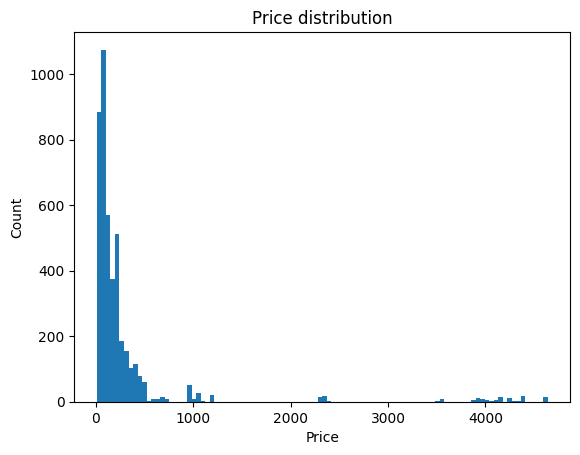

In [45]:
# price distribution check
plt.hist(df_skoda["price"], bins=100)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price distribution")
plt.show()

In [ ]:
# delete missing price 
df_skoda = df_skoda.dropna(subset=['price'])
print(df_skoda.shape)
print(df_skoda['price'].describe())

(4397, 15)
count    4397.000000
mean      288.648738
std       663.916553
min        11.800000
25%        59.200000
50%       130.200000
75%       237.200000
max      4641.000000
Name: price, dtype: float64


## 5. Clean Year


In [46]:
# year analysis
print(df_skoda['year'].dtype)
print(df_skoda['year'].head())
print(df_skoda['year'].describe())
print(df_skoda['year'].unique())

object
0    2013-2020
1    2013-2020
2    2020-2027
3    2020-2027
4    2013-2020
Name: year, dtype: object
count          4397
unique            4
top       2013-2020
freq           2647
Name: year, dtype: object
['2013-2020' '2020-2027' '2005-2013' '1996-2011']


In [48]:
df_skoda[['year_start', 'year_end']] = df_skoda['year'].str.split('-', expand=True)

df_skoda['year_start'] = pd.to_numeric(df_skoda['year_start'], errors='coerce')
df_skoda['year_end'] = pd.to_numeric(df_skoda['year_end'], errors='coerce')

df_skoda['year_span'] = df_skoda['year_end'] - df_skoda['year_start']
df_skoda['year_mid'] = (df_skoda['year_start'] + df_skoda['year_end']) / 2

print(df_skoda[['year','year_start', 'year_end', 'year_span', 'year_mid']].head())

# remove original column
df_skoda = df_skoda.drop(columns=['year'])

        year  year_start  year_end  year_span  year_mid
0  2013-2020        2013      2020          7    2016.5
1  2013-2020        2013      2020          7    2016.5
2  2020-2027        2020      2027          7    2023.5
3  2020-2027        2020      2027          7    2023.5
4  2013-2020        2013      2020          7    2016.5


## 6. Convert Dates


In [49]:
# Converting datetime 
df_skoda["scrape_date"] = pd.to_datetime(df_skoda["scrape_date"], errors="coerce")
df_skoda["scrape_date"].dtype

dtype('<M8[ns]')

## 7. Final Checks


In [51]:
# Final checks before merging
print(f" Mileage: {df_skoda['mileage'].dtype}")
print(f" Quality Grade: {df_skoda['quality_grade'].dtype}")
print(f" Missing Values: {df_skoda.isna().sum()}")

 Mileage: float64
 Quality Grade: object
 Missing Values: product_id       153
part_name          0
price              0
quality_grade      0
oem_number        95
mileage          405
brand              0
model              0
category           0
subcategory        0
scrape_date      153
year_start         0
year_end           0
year_span          0
year_mid           0
dtype: int64


In [52]:
# convert product id to integer
df_skoda["product_id"] = df_skoda["product_id"].astype("Int64")
df_skoda.dtypes

product_id                Int64
part_name                object
price                   float64
quality_grade            object
oem_number               object
mileage                 float64
brand                    object
model                    object
category                 object
subcategory              object
scrape_date      datetime64[ns]
year_start                int64
year_end                  int64
year_span                 int64
year_mid                float64
dtype: object

## 8. Preview Output


In [53]:
df_skoda.head()

,product_id,part_name,price,quality_grade,oem_number,mileage,brand,model,category,subcategory,scrape_date,year_start,year_end,year_span,year_mid
0,53484321,Contact roll Airbag -,177.6,A2,FI27837687A,301000.0,Skoda,Octavia,Airbag,Contact roll Airbag,2026-02-03,2013,2020,7,2016.5
1,57336303,Contact roll Airbag -,177.6,A2,FI27837687A,32000.0,Skoda,Octavia,Airbag,Contact roll Airbag,2026-02-03,2013,2020,7,2016.5
2,54668978,Contact roll Airbag -,177.6,A2,FI23857664A,30000.0,Skoda,Octavia,Airbag,Contact roll Airbag,2026-02-03,2020,2027,7,2023.5
3,53606519,Contact roll Airbag -,177.6,A1,FI02042722A,11000.0,Skoda,Octavia,Airbag,Contact roll Airbag,2026-02-03,2020,2027,7,2023.5
4,64799769,Contact roll Airbag -,177.6,A2,FI22893129A,195000.0,Skoda,Octavia,Airbag,Contact roll Airbag,2026-02-03,2013,2020,7,2016.5


## 9. Save Output


In [ ]:
#save cleaned csv
df_skoda.to_csv("skoda_cleaned.csv", index=False)